# Notebook 06 — Cohort & Retention Analysis

**Tier:** 2 — Diagnostic  
**Purpose:** Track whether customers acquired in earlier months return.  
**Input:** `outputs/feature_store.parquet`  
**Output:** `outputs/reports/cohort_retention_rate.csv`, `outputs/reports/cohort_gbv.csv`, charts  

> **Documented caveat:** With ~148,788 unique customers across 150,000 bookings, the
> vast majority appear only once. True month-over-month retention will be very low.
> This is real signal — high single-use / low-return behaviour — reported as a key finding.
> All revenue figures are **Gross Booking Value (GBV)** — not net revenue.

In [1]:
import os
os.chdir(r"D:\projects\Uber_Data_India_Analytics")
import sys, warnings, pathlib
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
pathlib.Path('outputs/plots').mkdir(parents=True, exist_ok=True)
pathlib.Path('outputs/reports').mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

df = pd.read_parquet('outputs/feature_store.parquet')
completed = df[df['is_completed']].copy()
slot_order = ['Early Morning','Morning','Afternoon','Evening','Night','Late Night']
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print(f'Loaded feature store: {df.shape}  |  completed: {len(completed):,}')

Loaded feature store: (150000, 46)  |  completed: 93,000


## 6.1 Cohort Construction

In [2]:
from src.cohort import (build_cohort_retention, build_cohort_retention_rate,
                        build_cohort_revenue, avg_retention_curve)

count_matrix = build_cohort_retention(df)
print(f'Cohort count matrix shape: {count_matrix.shape}')
print('Cohort sizes (month 0):')
print(count_matrix[0].to_string())

Cohort count matrix shape: (12, 12)
Cohort sizes (month 0):
cohort_month
2024-01    12858.0
2024-02    11895.0
2024-03    12682.0
2024-04    12129.0
2024-05    12706.0
2024-06    12351.0
2024-07    12795.0
2024-08    12510.0
2024-09    12085.0
2024-10    12498.0
2024-11    12222.0
2024-12    12057.0


## 6.2 Retention Rate Matrix

In [3]:
rate_matrix = build_cohort_retention_rate(count_matrix)
print('Cohort Retention Rate Matrix (%):', )
print(rate_matrix.to_string())
rate_matrix.to_csv('outputs/reports/cohort_retention_rate.csv')
print('\nSaved: outputs/reports/cohort_retention_rate.csv')

Cohort Retention Rate Matrix (%):
                 0    1    2    3    4    5    6    7    8    9    10   11
cohort_month                                                              
2024-01       100.0  0.2  0.1  0.2  0.1  0.1  0.2  0.1  0.1  0.1  0.2  0.1
2024-02       100.0  0.1  0.2  0.0  0.1  0.1  0.1  0.2  0.1  0.2  0.2  NaN
2024-03       100.0  0.1  0.2  0.1  0.1  0.2  0.2  0.1  0.1  0.2  NaN  NaN
2024-04       100.0  0.1  0.2  0.1  0.2  0.2  0.1  0.1  0.1  NaN  NaN  NaN
2024-05       100.0  0.1  0.1  0.1  0.1  0.1  0.2  0.1  NaN  NaN  NaN  NaN
2024-06       100.0  0.1  0.2  0.1  0.2  0.2  0.1  NaN  NaN  NaN  NaN  NaN
2024-07       100.0  0.1  0.2  0.1  0.1  0.1  NaN  NaN  NaN  NaN  NaN  NaN
2024-08       100.0  0.1  0.1  0.1  0.2  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2024-09       100.0  0.1  0.1  0.1  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2024-10       100.0  0.1  0.1  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2024-11       100.0  0.1  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  

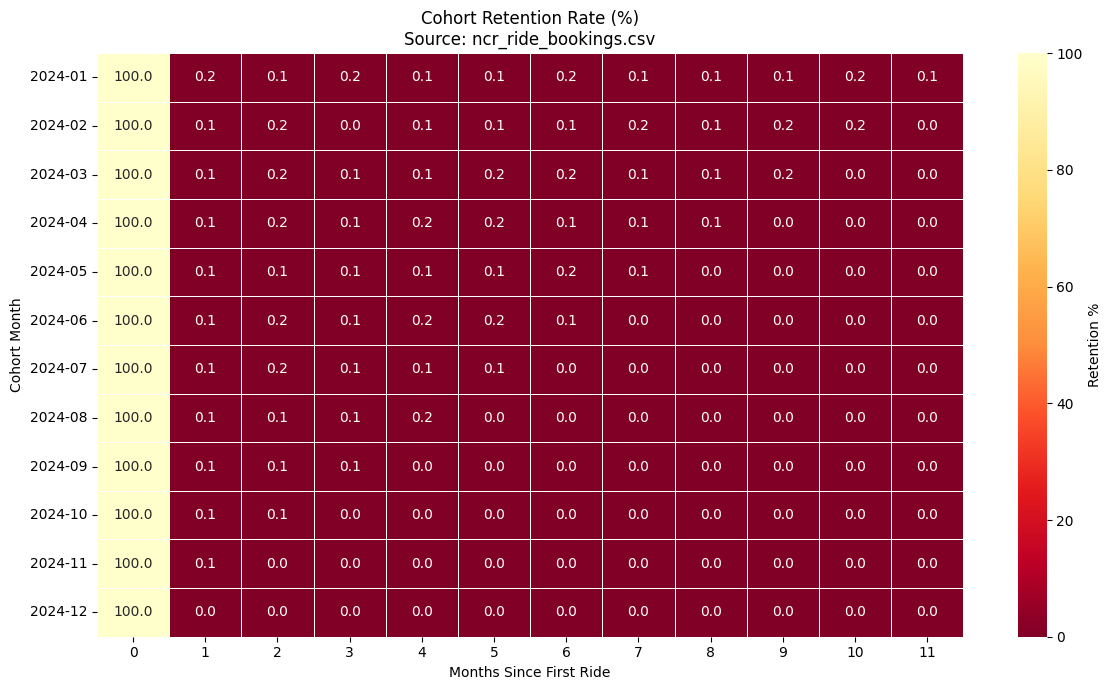

In [4]:
fig, ax = plt.subplots(figsize=(12, 7))
# Only plot columns up to the max available
cols_to_plot = [c for c in sorted(rate_matrix.columns) if c <= 11]
plot_data = rate_matrix[cols_to_plot].fillna(0)
sns.heatmap(plot_data, annot=True, fmt='.1f', cmap='YlOrRd_r',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Retention %'})
ax.set_title('Cohort Retention Rate (%)\nSource: ncr_ride_bookings.csv')
ax.set_xlabel('Months Since First Ride'); ax.set_ylabel('Cohort Month')
plt.tight_layout()
fig.savefig('outputs/plots/06_cohort_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Average Retention Curve (%):
0     100.0
1       0.1
2       0.2
3       0.1
4       0.1
5       0.1
6       0.2
7       0.1
8       0.1
9       0.2
10      0.2
11      0.1


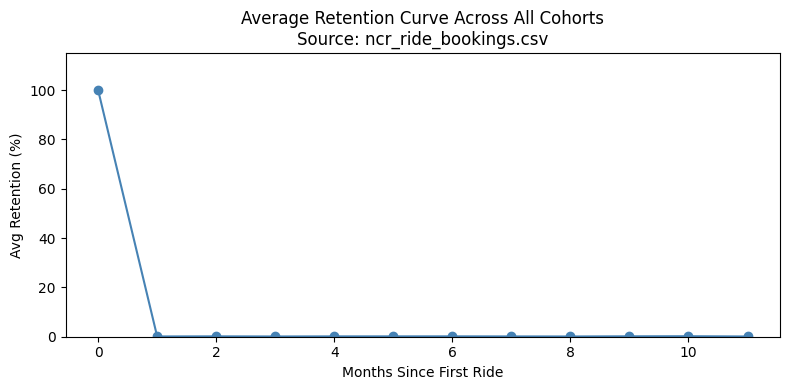

In [5]:
curve = avg_retention_curve(rate_matrix)
print('Average Retention Curve (%):', curve.round(1).to_string(), sep='\n')

fig, ax = plt.subplots(figsize=(8, 4))
curve.plot(kind='line', marker='o', ax=ax, color='steelblue')
ax.set_title('Average Retention Curve Across All Cohorts\nSource: ncr_ride_bookings.csv')
ax.set_xlabel('Months Since First Ride'); ax.set_ylabel('Avg Retention (%)')
ax.set_ylim(0, max(curve.max() * 1.15, 10))
plt.tight_layout()
fig.savefig('outputs/plots/06_retention_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.3 Revenue Cohort Matrix (GBV)

In [6]:
rev_matrix = build_cohort_revenue(df)
rev_matrix.to_csv('outputs/reports/cohort_gbv.csv')
print('Cohort GBV Matrix (₹):')
print(rev_matrix.fillna(0).applymap(lambda x: f'₹{x:,.0f}').to_string())
print('\nSaved: outputs/reports/cohort_gbv.csv')

Cohort GBV Matrix (₹):
                      0       1       2       3        4       5       6       7       8       9       10      11
cohort_month                                                                                                     
2024-01       ₹4,001,547  ₹4,148  ₹4,505  ₹9,507   ₹4,945  ₹3,838  ₹4,032  ₹5,858  ₹3,221  ₹1,826  ₹5,367  ₹7,656
2024-02       ₹3,752,462  ₹5,032  ₹5,899  ₹1,802   ₹3,076  ₹4,019  ₹3,949  ₹4,399  ₹5,776  ₹5,884  ₹5,628      ₹0
2024-03       ₹4,165,363  ₹4,898  ₹4,310  ₹1,860   ₹3,352  ₹6,667  ₹8,579  ₹9,470  ₹4,540  ₹4,955      ₹0      ₹0
2024-04       ₹3,864,951  ₹4,250  ₹8,404  ₹2,567   ₹5,299  ₹3,995  ₹2,920  ₹6,088  ₹4,833      ₹0      ₹0      ₹0
2024-05       ₹3,919,900  ₹8,048  ₹5,118  ₹1,516   ₹4,570  ₹4,556  ₹5,760  ₹4,903      ₹0      ₹0      ₹0      ₹0
2024-06       ₹3,939,072  ₹3,829  ₹4,913  ₹4,216   ₹8,347  ₹6,175  ₹4,899      ₹0      ₹0      ₹0      ₹0      ₹0
2024-07       ₹3,939,022  ₹4,518  ₹6,403  ₹4,075   ₹3,056  ₹6,580

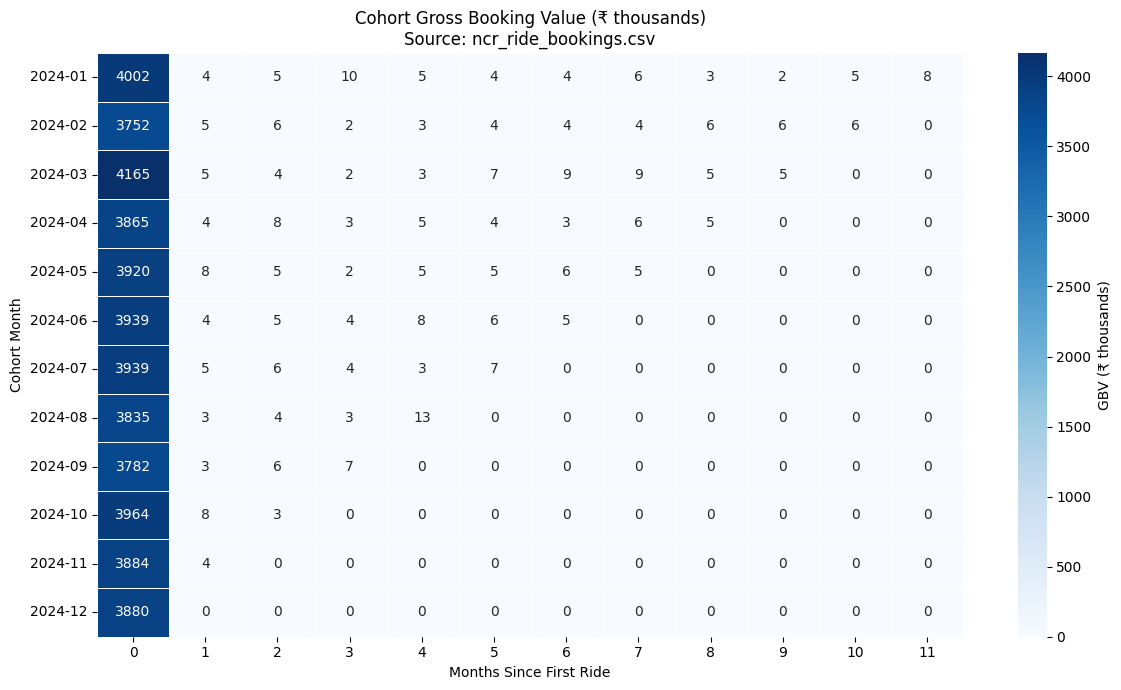

In [7]:
fig, ax = plt.subplots(figsize=(12, 7))
rev_cols = [c for c in sorted(rev_matrix.columns) if c <= 11]
rev_plot = rev_matrix[rev_cols].fillna(0)
sns.heatmap(rev_plot / 1000, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'GBV (₹ thousands)'})
ax.set_title('Cohort Gross Booking Value (₹ thousands)\nSource: ncr_ride_bookings.csv')
ax.set_xlabel('Months Since First Ride'); ax.set_ylabel('Cohort Month')
plt.tight_layout()
fig.savefig('outputs/plots/06_cohort_gbv_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.4 Key Cohort Findings

In [8]:
# Month-0 vs Month-1 drop (the critical churn point)
if 0 in rate_matrix.columns and 1 in rate_matrix.columns:
    m0_to_m1_drop = (rate_matrix[0] - rate_matrix[1].fillna(0)).mean()
    print(f'Average Month-0 → Month-1 retention drop: {m0_to_m1_drop:.1f} percentage points')

# Best-retention cohort
best_cohort = rate_matrix[1].fillna(0).idxmax() if 1 in rate_matrix.columns else 'N/A'
print(f'Cohort with best Month-1 retention: {best_cohort}')

# Trend: is retention improving for later cohorts?
if 1 in rate_matrix.columns:
    early = rate_matrix.iloc[:3][1].fillna(0).mean()
    late  = rate_matrix.iloc[-3:][1].fillna(0).mean()
    trend = 'improving' if late > early else 'declining'
    print(f'Month-1 retention trend (early vs late cohorts): {trend}  ({early:.1f}% → {late:.1f}%)')

Average Month-0 → Month-1 retention drop: 99.9 percentage points
Cohort with best Month-1 retention: 2024-01
Month-1 retention trend (early vs late cohorts): declining  (0.1% → 0.1%)


## Limitations
- True LTV cannot be calculated — no cost data (driver payout, commission, operating cost).
- All revenue figures are GBV only.
- With ~1 ride per customer on average, cohort retention is structurally low — this is treated as a genuine finding, not a data issue.